## **SUMMARY**
This script is used to create an inventory using raw NSI point data. Steps include inferring structure type and exporting in an R2D-Compatible format. 



In [1]:
# Copyright (c) 2025, Meredith Lochhead
# All rights reserved.
#
# This source code is licensed under the BSD 3-Clause License found in the
# LICENSE file in the root directory of this source tree.

In [2]:
# Relevant python functions
import pandas as pd
import geopandas as gpd
import random
import matplotlib.pyplot as plt
import folium 
import os
import sys

# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)

import functions_general as fxns
import functions_preprocessing as pre
import functions_disagreement_and_gaps as resolve

In [3]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4269' # Used for plotting 

# HAYWARD BOUNDS
xbounds = [-122.15, -122.02]
ybounds = [37.60, 37.69]

In [4]:
# Create Output Directory
name = 'NSI26_Point' # This will be the name of the inventory within the R2D folder
dir_r2d = './R2D_Analysis/Inventories/' + name + '/'
os.makedirs(dir_r2d, exist_ok=True)

### **Filter Raw NSI Data and Rename Columns**

522
744


Text(0.5, 1.0, 'NSI Points within Hayward')

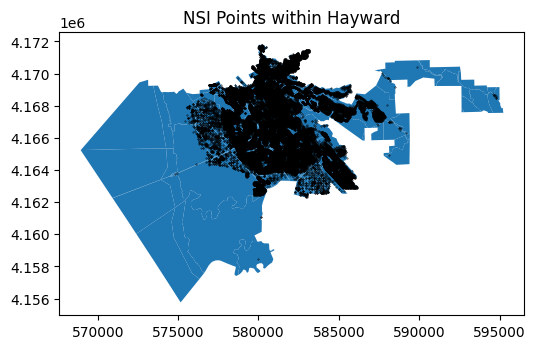

In [5]:
##### LOAD NSI DATA DOWNLOADED USING BRAILS TOOL AND CONVERT TO APPROPRIATE CRS #####
nsi = gpd.read_file('./Input_Data/National/nsi_2026/06001.gpkg')
nsi = nsi.to_crs(epsg=crs_main)


# ##### RENAME AND DROP NSI COLUMNS AS APPROPRIATE #####
# # Note - if different columns present in the nsi dataframe than in the case of Hayward, go to the 
# # rename_nsi_data function and comment out / add appropriate column names as needed 
# nsi = pre.rename_nsi_data(nsi.copy())


# Drop unnecessary columns from NSI data
nsi.drop(['USASTRUCID','ST_DAMCAT', 'FTPRNTID', 'BSMNT', 'VEHPERUNIT', 'PCTLOWCLR','VAL_VEHIC','CENSREGION','POP_CI95_L','POP_MEDIAN',
       'POP_CI95_U', 'SVI', 'FLD_ZONE', 'ZONE_SUBTY', 'STATIC_BFE','NOVEHPROB','U65DISABLE','O65DISABLE','DEPRECIATN','HEIGHT', 'X', 'Y'], 
                    axis=1, inplace=True)

# Rename columns to more meaningful names
nsi = nsi.rename(columns={
    'FNDTYPE': 'NSI_FoundationType',
    'FOUND_HT': 'NSI_FoundationHeight',
    'EXTWALL': 'NSI_BuildingType',
    'MED_YR_BLT': 'NSI_MedYearBuilt',
    'CBFIPS2020': 'CensusBlock',
    'OCCTYPE': 'NSI_OccupancyClass',
    'NUM_STORY': 'NSI_NumberOfStories',
    'SOURCE': 'NSI_OrigSource',
    'FTPRNTSRC': 'NSI_OrigFtptSource',
    'BID': 'NSI_BID',
    'SQFT': 'NSI_TotalAreaSqFt',
    'RESUNITS': 'NSI_Units',
    'POP2AMU65': 'NSI_PopUnder65_Night',
    'POP2AMO65': 'NSI_PopOver65_Night',
    'POP2PMU65': 'NSI_PopUnder65_Day',
    'POP2PMO65': 'NSI_PopOver65_Day',
    'VAL_CONT': 'NSI_ContentValue',
    'VAL_STRUCT': 'NSI_StructureValue',
    'STUDENTS': 'NSI_Students',
    'REPLCVALUE': 'NSI_ReplacementCost'})
nsi['NSI_Population_Night'] = nsi[['NSI_PopUnder65_Night', 'NSI_PopOver65_Night']].sum(axis=1)
nsi['NSI_Population_Day'] = nsi[['NSI_PopUnder65_Day', 'NSI_PopOver65_Day']].sum(axis=1)


# For consistency with 2022, set replacement cost as sum of structure value and content value 
print(round(nsi['NSI_ReplacementCost'].sum()/10**9))
nsi['NSI_ReplacementCost'] = nsi[['NSI_ContentValue', 'NSI_StructureValue']].sum(axis=1)
print(round(nsi['NSI_ReplacementCost'].sum()/10**9))


##### CHECK AND ASSIGN CENSUS BLOCK INFORMATION FOR NSI DATA #####
# Load Census blocks and tracts 
hayward_blocks = gpd.read_file('./Input_Data/Census/Census2020/Hayward_blocks.geojson')
hayward_tracts = gpd.read_file('./Input_Data/Census/Census2020/Hayward_tracts.geojson')

# # Merge NSI data with City-Specific Census Blocks and check for errors in NSI data
# nsi = pre.assign_point_block_and_track(nsi, hayward_blocks, hayward_tracts)
nsi = nsi[nsi['CensusBlock'].isin(hayward_blocks['GEOID20'].to_list())].copy()


# Standardize RES1 occupancy Types for consistency with other inventories
nsi['NSI_OccupancyClass'] = nsi['NSI_OccupancyClass'].apply(lambda x: 'RES1' if 'RES1' in str(x) else x)


# Plot Results
fig, ax = plt.subplots(1,1, figsize = (6, 6))
hayward_blocks.plot(ax=ax)
nsi.plot(ax=ax, color ='black', markersize = 0.1)
ax.set_title('NSI Points within Hayward')

In [6]:
# ### UNCOMMENT CODE TO PLOT INTERACTIVE MAP WITH FOOTPRINTS AND NSI POINTS

# hayward10 = gpd.read_file('./Input_Data/Census/Census2010/Hayward_blocks.geojson')

# # Create a base map
# m = folium.Map(location=[hayward10.copy().to_crs(crs_plot).geometry.iloc[0].centroid.y, hayward10.copy().to_crs(crs_plot).geometry.iloc[0].centroid.x], zoom_start=12)

# # Add footprints (polygons)
# folium.GeoJson(hayward10.copy().to_crs(crs_plot), color = 'gray').add_to(m)

# # Add remaining points     
# for idx, row in nsi.copy().to_crs(crs_plot).iterrows():
#     folium.CircleMarker(location=[row.geometry.y, row.geometry.x], 
#                         radius=1, 
#                         color='blue', 
#                         fill=True, 
#                         fill_color='blue').add_to(m)

# display(m)

### **Infer Structure Type**


In [7]:
# SET FLAG 
use_bldg_type = True # Use building type (material) to constrain list of possible structure types  
allow_mh_only_for_res2 = False # Allows structure type 'MH' only when the occupancy class is RES2 (diverges from Hazus) 
no_urm = False # Doesn't allow the assignment of URM buildings, due to efforts to retrofit those buildings (diverges from Hazus)
res3ab_to_res1_flag = True # Adopts structure types used for 'RES1' to be assigned for RES3A and RES3B. 2-4 unit structures are likely structurally more similar to single family homes than to large apartment buildings. 


# SET VARIABLE NAMES
state = 'California'
occ_key = 'NSI_OccupancyClass'
nstory_key = 'NSI_NumberOfStories'
year_key = 'NSI_MedYearBuilt'
strtype_key = 'StructureType'
bldgtype_key = 'NSI_BuildingType'
n_pw = 1

# CALL FUNCTION TO INFER STRUCTURE TYPE
bldg_properties_df = resolve.infer_structure_type(nsi.copy(), state, occ_key, nstory_key, year_key, bldgtype_key, strtype_key, n_pw, use_bldg_type, allow_mh_only_for_res2, no_urm, res3ab_to_res1_flag)



CHECK: Regions considered in structure type assignment: ['West Coast']
HAZUS does not provide structural type information for West Coast-RES2-low_rise-1950_to_1970-W
Num Buildings in that Class: 4
HAZUS does not provide structural type information for West Coast-RES2-low_rise-post_1970-W
Num Buildings in that Class: 277
HAZUS does not provide structural type information for West Coast-GOV1-mid_rise-post_1970-W
Num Buildings in that Class: 2
HAZUS does not provide structural type information for West Coast-COM7-high_rise-1950_to_1970-S
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-COM7-high_rise-post_1970-S
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-IND4-low_rise-1950_to_1970-W
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-GOV2-low_rise-1950_to_1970-S
Num Buildings in that Class: 1
HAZUS does not provide structural type information f

/Users/mialochhead/Documents/GitHub/Building_Inventory_Generation/inventory_generation_functions/functions_disagreement_and_gaps.py:1320: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'MH' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  bldg_properties_df.loc[index, 'StructureType'] = feature['StructureType']


In [8]:
## REPEAT INFER PROCESS AND REMOVE BUILDING TYPES THAT ARE MISSING HAZUS FRAGILITY FUNCTIONS 

# Load best estimate inventory 
alldata = bldg_properties_df.copy()


missing_structuretype = alldata[((alldata['StructureType'].isna()) | (alldata['StructureType']=='na'))].copy()
has_structuretype = alldata[~((alldata['StructureType'].isna()) | (alldata['StructureType']=='na'))].copy()

# Check if any data lost
if len(missing_structuretype) + len(has_structuretype) != len(alldata):
    raise ValueError('Data Lost')

# SET FLAG 
use_bldg_type = False # Use building type (material) to constrain list of possible structure types  
allow_mh_only_for_res2 = False # Allows structure type 'MH' only when the occupancy class is RES2 (diverges from Hazus) 
no_urm = False # Doesn't allow the assignment of URM buildings, due to efforts to retrofit those buildings (diverges from Hazus)
res3ab_to_res1_flag = True # Adopts structure types used for 'RES1' to be assigned for RES3A and RES3B. 2-4 unit structures are likely structurally more similar to single family homes than to large apartment buildings. 


# CALL FUNCTION TO INFER STRUCTURE TYPE
bldg_properties_df = resolve.infer_structure_type(missing_structuretype.copy(), state, occ_key, nstory_key, year_key, bldgtype_key, strtype_key, n_pw, use_bldg_type, allow_mh_only_for_res2, no_urm, res3ab_to_res1_flag)


# Recombine dataframes 
recombined_gdf = gpd.GeoDataFrame(pd.concat([has_structuretype, bldg_properties_df], ignore_index=True))

# Check if any data lost
if len(recombined_gdf) != len(alldata):
    raise ValueError('Data Lost')

CHECK: Regions considered in structure type assignment: ['West Coast']
HAZUS does not provide structural type information for West Coast-IND2-mid_rise-post_1970
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-IND2-high_rise-1950_to_1970
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-COM8-high_rise-post_1970
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-EDU1-mid_rise-1950_to_1970
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-EDU1-mid_rise-post_1970
Num Buildings in that Class: 5
HAZUS does not provide structural type information for West Coast-COM7-high_rise-1950_to_1970
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-COM7-high_rise-post_1970
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-COM

### **Export for R2D**


In [9]:
# Convert to format of R2D - remove missing data 
bldg_properties_df_nomissing = recombined_gdf[~((recombined_gdf['StructureType'].isna()) | (recombined_gdf['StructureType']=='na'))].copy()
print(len(recombined_gdf[((recombined_gdf['StructureType'].isna()) | (recombined_gdf['StructureType']=='na'))].copy()), 'points dropped due to missing structure type')


# Compute plan area 
bldg_properties_df_nomissing['NSI_PlanAreaSqFt'] = bldg_properties_df_nomissing['NSI_TotalAreaSqFt'] / bldg_properties_df_nomissing['NSI_NumberOfStories']

# Create appropriate columns
r2d = bldg_properties_df_nomissing.copy().to_crs('EPSG:4269')
r2d['Longitude'] = r2d['geometry'].x
r2d['Latitude'] = r2d['geometry'].y

r2d = r2d[['Latitude','Longitude','NSI_PlanAreaSqFt','NSI_NumberOfStories','NSI_MedYearBuilt','NSI_ReplacementCost','NSI_StructureValue','NSI_BuildingType','StructureType','NSI_OccupancyClass','NSI_OccupancyClass_clean','NSI_Population_Night','geometry']]

# Rename columns for R2D use
r2d = r2d.rename(columns={'NSI_OccupancyClass': 'OccupancyClass_Actual',
                          'NSI_OccupancyClass_clean': 'OccupancyClass',
                          'NSI_NumberOfStories': 'NumberOfStories',
                          'NSI_PlanAreaSqFt':'PlanArea',
                          'NSI_MedYearBuilt':'YearBuilt',
                          'NSI_BuildingType': 'BuildingType',
                          'NSI_Population_Night':'NightPopulation',
                          'NSI_ReplacementCost':'ReplacementCost',
                          'NSI_StructureValue':'StructureValue'})

# Assign design level and height class (used in regional analysis)
r2d = resolve.find_design_level(r2d, 'StructureType', 'YearBuilt', 'DesignLevel')
r2d = resolve.find_height_class(r2d, 'StructureType', 'NumberOfStories', 'HeightClass')

# Add id
r2d.insert(0, 'id', range(len(r2d)))

# Save inventory
r2d.to_csv(dir_r2d + 'R2D_Inventory.csv', index = False)
fxns.gdf_to_json(r2d, dir_r2d + 'R2D_Inventory.json')

# Randomly sample for R2D test run 
sampled_df = r2d.sample(n=50, random_state=1, replace = False)
sampled_df = sampled_df.drop(columns='id')
sampled_df.insert(0, 'id', range(len(sampled_df)))
sampled_df.to_csv(dir_r2d + 'R2D_Inventory_SAMPLED.csv', index = False)



13 points dropped due to missing structure type
JSON File Saved


In [10]:
print(r2d['ReplacementCost'].sum()/10**9)
print(r2d['StructureValue'].sum()/10**9)

76.42062283345999
41.878192813919995
